# Fraud Detection - Notebook 6: Explainability Layer with SHAP

This notebook builds and tests the **Explainability Layer** for the selected production fraud detection stack.

The selected production model is:

- **Base models:** Random Forest, CatBoost, XGBoost
- **Meta-model:** Logistic Regression stacking model
- **Meta-feature vector:** `<rf_prob, cat_prob, xgb_prob>`
- **Selected business threshold:** `0.69`
- **Decision rule:** probability >= threshold → `BLOCK`, otherwise → `ALLOW`

The goal of this notebook is **not to train a new model**.

The goal is to test how the backend can generate reliable explanations after a prediction is produced.

## Why Explainability Is Separate from Prediction

The prediction stack answers this question:

> What is the fraud probability of this transaction?

The explainability layer answers a different question:

> Which transaction features pushed the model toward a higher fraud-risk decision?

These two responsibilities must stay separate in backend architecture.

Prediction logic belongs in `PredictionService`.
Explanation logic belongs in `ExplanationService`.
Decision orchestration belongs in `FraudDecisionService`.
API formatting belongs in `ResponseBuilder`.

## Important Design Choice

The final Logistic Regression meta-model only receives three values:

```text
[rf_prob, cat_prob, xgb_prob]
```

Therefore, the meta-model can explain **which base model probabilities influenced the final stack**, but it cannot directly explain which original transaction fields caused the fraud risk.

For transaction-level explanations, we use SHAP on a tree-based base model, primarily **CatBoost**, because it is one of the strongest models in the selected stack and works well with SHAP.

The final explanation combines two levels:

1. **Stack-level explanation**  
   Explains how RF, CatBoost, and XGBoost scores affected the final Logistic Regression output.

2. **Transaction-level explanation**  
   Uses SHAP on CatBoost to identify the original processed features that contributed most to the fraud-risk score.

# 1. Install and Import Packages

In [ ]:
%%capture
!pip install -q ipython-autotime
!pip install -q gdown kagglehub shap joblib pandas numpy scikit-learn xgboost catboost
%load_ext autotime

time: 336 µs (started: 2026-06-22 08:03:45 +00:00)


In [ ]:
import os
import json
import joblib
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import gdown
import kagglehub
import shap

from IPython.display import display
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

time: 5.91 s (started: 2026-06-22 08:03:45 +00:00)


# 2. Configuration

The selected threshold comes from the business optimization study.
It is used to convert the final fraud probability into an operational decision.

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SELECTED_STACK_NAME = "RF + CAT + XGB"
SELECTED_META_FEATURES = ["rf_prob", "cat_prob", "xgb_prob"]
PRODUCTION_THRESHOLD = 0.69

LABEL_ALLOW = "ALLOW"
LABEL_BLOCK = "BLOCK"

print("Selected stack:", SELECTED_STACK_NAME)
print("Selected meta features:", SELECTED_META_FEATURES)
print("Production threshold:", PRODUCTION_THRESHOLD)

Selected stack: RF + CAT + XGB
Selected meta features: ['rf_prob', 'cat_prob', 'xgb_prob']
Production threshold: 0.69
time: 818 µs (started: 2026-06-22 08:03:51 +00:00)


# 3. Download Production Artifacts

This notebook uses the same saved artifacts as the selected-stack inference notebook.

Required artifacts:

- `preprocessing_artifacts.joblib`
- `random_forest.joblib`
- `catboost.cbm`
- `xgboost.json`
- `production_stack_artifacts.joblib`

No training is performed here.

In [ ]:
ARTIFACT_DIR = "/content/fraud_explainability_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

artifact_file_ids = {
    "preprocessing_artifacts.joblib": "12wDMl5MU6kNcLoFXTKw3Ex51853OzdCZ",
    "random_forest.joblib": "12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC",
    "catboost.cbm": "1c8QLXfW0rp3H3M9dyS4obI43oxPMjrAn",
    "xgboost.json": "1AerxFemFwZQita5ni0IQK4eJ19vBN7n_",
    "production_stack_artifacts.joblib": "1gvPe7Gu3MBmp4-XGII7I4N79_vUGge6N",
}

artifact_paths = {}

for filename, file_id in artifact_file_ids.items():
    output_path = os.path.join(ARTIFACT_DIR, filename)
    artifact_paths[filename] = output_path

    if not os.path.exists(output_path):
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, output_path, quiet=False)

print("Artifact paths:")
for name, path in artifact_paths.items():
    print(name, "->", path)

Downloading...
From: https://drive.google.com/uc?id=12wDMl5MU6kNcLoFXTKw3Ex51853OzdCZ
To: /content/fraud_explainability_artifacts/preprocessing_artifacts.joblib
100%|██████████| 33.3k/33.3k [00:00<00:00, 51.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC
From (redirected): https://drive.google.com/uc?id=12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC&confirm=t&uuid=23030aa1-1838-4aa5-807a-ea9763e53113
To: /content/fraud_explainability_artifacts/random_forest.joblib
100%|██████████| 125M/125M [00:00<00:00, 175MB/s]
Downloading...
From: https://drive.google.com/uc?id=1c8QLXfW0rp3H3M9dyS4obI43oxPMjrAn
To: /content/fraud_explainability_artifacts/catboost.cbm
100%|██████████| 1.49M/1.49M [00:00<00:00, 203MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AerxFemFwZQita5ni0IQK4eJ19vBN7n_
To: /content/fraud_explainability_artifacts/xgboost.json
100%|██████████| 2.24M/2.24M [00:00<00:00, 22.7MB/s]
Downloading...
From: https://drive.google.com/u

Artifact paths:
preprocessing_artifacts.joblib -> /content/fraud_explainability_artifacts/preprocessing_artifacts.joblib
random_forest.joblib -> /content/fraud_explainability_artifacts/random_forest.joblib
catboost.cbm -> /content/fraud_explainability_artifacts/catboost.cbm
xgboost.json -> /content/fraud_explainability_artifacts/xgboost.json
production_stack_artifacts.joblib -> /content/fraud_explainability_artifacts/production_stack_artifacts.joblib
time: 7.44 s (started: 2026-06-22 08:03:51 +00:00)


# 4. Load Production Artifacts

In [ ]:
preprocessing_artifacts = joblib.load(
    artifact_paths["preprocessing_artifacts.joblib"]
)

rf_model = joblib.load(
    artifact_paths["random_forest.joblib"]
)

cat_model = CatBoostClassifier()
cat_model.load_model(
    artifact_paths["catboost.cbm"]
)

xgb_model = XGBClassifier()
xgb_model.load_model(
    artifact_paths["xgboost.json"]
)

production_stack_artifacts = joblib.load(
    artifact_paths["production_stack_artifacts.joblib"]
)

meta_model = production_stack_artifacts["meta_model"]
production_feature_set = list(production_stack_artifacts["feature_set"])
production_threshold_from_artifact = float(production_stack_artifacts["threshold"])

print("All artifacts loaded successfully.")
print("Production feature set:", production_feature_set)
print("Threshold from artifact:", production_threshold_from_artifact)

All artifacts loaded successfully.
Production feature set: ['rf_prob', 'cat_prob', 'xgb_prob']
Threshold from artifact: 0.69
time: 792 ms (started: 2026-06-22 08:03:58 +00:00)


In [ ]:
assert production_feature_set == SELECTED_META_FEATURES

# In production, prefer the threshold saved in the artifact.
# The constant 0.69 is kept for readability and project documentation.
production_threshold = production_threshold_from_artifact

print("Final threshold used:", production_threshold)

Final threshold used: 0.69
time: 538 µs (started: 2026-06-22 08:03:59 +00:00)


# 5. Feature Engineering and Preprocessing

This section must match the training and inference notebooks.

The model was trained on engineered features such as transaction hour, customer age, weekend flag, and distance between customer and merchant.

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def add_features(df):
    df = df.copy()

    df = df.drop(
        columns=[col for col in ["Unnamed: 0"] if col in df.columns],
        errors="ignore"
    )

    if "trans_date_trans_time" in df.columns:
        trans_time = pd.to_datetime(
            df["trans_date_trans_time"],
            errors="coerce"
        )

        df["hour"] = trans_time.dt.hour
        df["day_of_week"] = trans_time.dt.dayofweek
        df["month"] = trans_time.dt.month
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    else:
        trans_time = None

    if "dob" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")

        if trans_time is not None:
            df["age"] = trans_time.dt.year - dob.dt.year
        else:
            df["age"] = 2020 - dob.dt.year

        df["age"] = df["age"].clip(lower=0, upper=100)

    required_distance_cols = {"lat", "long", "merch_lat", "merch_long"}

    if required_distance_cols.issubset(df.columns):
        df["distance_km"] = haversine_distance(
            df["lat"],
            df["long"],
            df["merch_lat"],
            df["merch_long"]
        )

    drop_cols = [
        "trans_date_trans_time",
        "cc_num",
        "first",
        "last",
        "street",
        "city",
        "state",
        "zip",
        "trans_num",
        "unix_time",
        "dob",
    ]

    df = df.drop(
        columns=[col for col in drop_cols if col in df.columns],
        errors="ignore"
    )

    return df

time: 2.08 ms (started: 2026-06-22 08:03:59 +00:00)


In [ ]:
def preprocess_for_inference(raw_df):
    df = raw_df.copy()
    df = add_features(df)

    if "is_fraud" in df.columns:
        df = df.drop(columns=["is_fraud"])

    encoder = preprocessing_artifacts["encoder"]
    medians = preprocessing_artifacts["medians"]
    feature_columns = preprocessing_artifacts["feature_columns"]
    categorical_columns = preprocessing_artifacts["categorical_columns"]

    missing_columns = [
        col for col in feature_columns
        if col not in df.columns
    ]

    for col in missing_columns:
        df[col] = np.nan

    if categorical_columns:
        for col in categorical_columns:
            if col not in df.columns:
                df[col] = "missing"

        df[categorical_columns] = encoder.transform(
            df[categorical_columns].astype(str)
        )

    df = df[feature_columns]
    df = df.fillna(medians)

    return df

time: 884 µs (started: 2026-06-22 08:03:59 +00:00)


# 6. PredictionService

`PredictionService` is responsible only for prediction.

It receives a transaction, applies preprocessing, runs the selected base models, creates the meta-feature vector, runs the meta-model, and returns the final probability and decision.

In [ ]:
class PredictionService:
    def __init__(
        self,
        rf_model,
        cat_model,
        xgb_model,
        meta_model,
        threshold,
        meta_feature_order,
    ):
        self.rf_model = rf_model
        self.cat_model = cat_model
        self.xgb_model = xgb_model
        self.meta_model = meta_model
        self.threshold = threshold
        self.meta_feature_order = meta_feature_order

    def predict(self, raw_transaction_df):
        processed_features = preprocess_for_inference(raw_transaction_df)

        rf_prob = float(
            self.rf_model.predict_proba(processed_features)[:, 1][0]
        )
        cat_prob = float(
            self.cat_model.predict_proba(processed_features)[:, 1][0]
        )
        xgb_prob = float(
            self.xgb_model.predict_proba(processed_features)[:, 1][0]
        )

        meta_features_df = pd.DataFrame({
            "rf_prob": [rf_prob],
            "cat_prob": [cat_prob],
            "xgb_prob": [xgb_prob],
        })

        meta_features_df = meta_features_df[self.meta_feature_order]

        final_probability = float(
            self.meta_model.predict_proba(meta_features_df)[:, 1][0]
        )

        decision = (
            LABEL_BLOCK
            if final_probability >= self.threshold
            else LABEL_ALLOW
        )

        return {
            "final_probability": final_probability,
            "decision": decision,
            "threshold": float(self.threshold),
            "base_model_scores": {
                "rf": rf_prob,
                "cat": cat_prob,
                "xgb": xgb_prob,
            },
            "meta_features": meta_features_df,
            "processed_features": processed_features,
        }

time: 1.25 ms (started: 2026-06-22 08:03:59 +00:00)


# 7. SHAP Explainer Setup

SHAP is used to explain how individual features influenced a model prediction.

For this project, we use SHAP on **CatBoost** as the primary transaction-level explainer.

Why CatBoost?

- It is one of the selected production base models.
- It is a tree-based model, which works well with SHAP.
- It performed strongly in the selected stack.
- It explains original processed transaction features, not only meta-model probabilities.

In [ ]:
cat_shap_explainer = shap.TreeExplainer(cat_model)

print("CatBoost SHAP explainer is ready.")

CatBoost SHAP explainer is ready.
time: 296 ms (started: 2026-06-22 08:03:59 +00:00)


# 8. Business Explanation Mapping

SHAP returns feature names and contribution values.

The function below converts technical feature names into readable business explanations for the analyst dashboard.

In [ ]:
BUSINESS_REASON_MAP = {
    "amt": "Transaction amount contributed to the fraud-risk score.",
    "category": "Merchant category pattern contributed to the fraud-risk score.",
    "merchant": "Merchant identity pattern contributed to the fraud-risk score.",
    "gender": "Encoded customer profile signal contributed to the model score.",
    "job": "Customer occupation pattern contributed to the model score.",
    "lat": "Customer location signal contributed to the model score.",
    "long": "Customer location signal contributed to the model score.",
    "merch_lat": "Merchant location signal contributed to the model score.",
    "merch_long": "Merchant location signal contributed to the model score.",
    "city_pop": "Customer city population context contributed to the model score.",
    "hour": "Transaction time of day contributed to the fraud-risk score.",
    "day_of_week": "Day-of-week timing pattern contributed to the fraud-risk score.",
    "month": "Monthly timing pattern contributed to the fraud-risk score.",
    "is_weekend": "Weekend transaction pattern contributed to the fraud-risk score.",
    "age": "Customer age signal contributed to the model score.",
    "distance_km": "Distance between customer and merchant contributed to the fraud-risk score.",
}


def get_business_reason(feature_name):
    return BUSINESS_REASON_MAP.get(
        feature_name,
        "This feature contributed to the model fraud-risk score."
    )

time: 952 µs (started: 2026-06-22 08:03:59 +00:00)


# 9. ExplanationService

`ExplanationService` receives the prediction result and creates two outputs:

1. A detailed internal explanation for an analyst or agent.
2. A safe external message for the customer.

The customer message must not expose thresholds, model internals, SHAP values, rules, or exact feature names.

In [ ]:
class ExplanationService:
    def __init__(self, shap_explainer, top_n=5):
        self.shap_explainer = shap_explainer
        self.top_n = top_n

    def explain_with_catboost_shap(self, processed_features):
        shap_values = self.shap_explainer.shap_values(processed_features)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        shap_values_for_row = np.array(shap_values[0])

        shap_df = pd.DataFrame({
            "feature": processed_features.columns,
            "value": processed_features.iloc[0].values,
            "shap_value": shap_values_for_row,
            "absolute_shap_value": np.abs(shap_values_for_row),
        })

        shap_df = shap_df.sort_values(
            "absolute_shap_value",
            ascending=False
        ).reset_index(drop=True)

        shap_df["direction"] = np.where(
            shap_df["shap_value"] > 0,
            "increased fraud risk",
            "reduced fraud risk"
        )

        shap_df["business_reason"] = shap_df["feature"].apply(
            get_business_reason
        )

        return shap_df

    def build_agent_explanation(
        self,
        original_transaction,
        prediction_result,
    ):
        shap_df = self.explain_with_catboost_shap(
            prediction_result["processed_features"]
        )

        top_positive = shap_df[
            shap_df["shap_value"] > 0
        ].head(self.top_n)

        top_risk_factors = []

        for _, row in top_positive.iterrows():
            top_risk_factors.append({
                "feature": row["feature"],
                "processed_value": float(row["value"]),
                "shap_value": float(row["shap_value"]),
                "direction": row["direction"],
                "business_reason": row["business_reason"],
            })

        base_scores = prediction_result["base_model_scores"]
        agreeing_models = [
            model_name.upper()
            for model_name, score in base_scores.items()
            if score >= 0.5
        ]

        if prediction_result["decision"] == LABEL_BLOCK:
            summary = (
                "Transaction was blocked because the stacked model "
                "estimated a fraud probability above the selected business threshold. "
                "The explanation below shows the strongest CatBoost feature-level "
                "signals that increased the fraud-risk score for this specific transaction."
            )
        else:
            summary = (
                "Transaction was allowed because the stacked model estimated a fraud "
                "probability below the selected business threshold. The explanation below "
                "shows the strongest model signals for review."
            )

        technical_details = {
            "explanation_method": "CatBoost Tree SHAP",
            "stack_level_model": "Logistic Regression over RF, CatBoost, and XGBoost probabilities",
            "base_models_above_0_5": agreeing_models,
            "note": (
                "SHAP values explain the CatBoost base-model contribution at the "
                "transaction-feature level. The final decision is still made by the "
                "Logistic Regression stacking model."
            ),
        }

        return {
            "summary": summary,
            "top_risk_factors": top_risk_factors,
            "technical_details": technical_details,
            "shap_table": shap_df,
        }

    def build_customer_message(self, prediction_result):
        if prediction_result["decision"] == LABEL_BLOCK:
            return {
                "title": "Transaction Verification Needed",
                "message": (
                    "Hi, we noticed an unusual transaction attempt on your card. "
                    "To help protect your account, we temporarily stopped the transaction "
                    "and would like to verify that it was initiated by you. "
                    "If this was you, please confirm and try again."
                )
            }

        return {
            "title": "Transaction Approved",
            "message": (
                "Your transaction was approved. No additional verification is needed."
            )
        }

    def explain(self, original_transaction, prediction_result):
        agent_explanation = self.build_agent_explanation(
            original_transaction=original_transaction,
            prediction_result=prediction_result,
        )

        customer_message = self.build_customer_message(
            prediction_result=prediction_result,
        )

        return agent_explanation, customer_message

time: 2.57 ms (started: 2026-06-22 08:03:59 +00:00)


# 10. ResponseBuilder

`ResponseBuilder` creates a clean JSON object for the frontend.

The frontend can use the same response in two different screens:

- Agent dashboard: prediction + internal explanation
- Customer screen: safe customer message only

In [ ]:
class ResponseBuilder:
    @staticmethod
    def build(prediction_result, agent_explanation, customer_message):
        return {
            "prediction": {
                "decision": prediction_result["decision"],
                "fraud_probability": round(
                    prediction_result["final_probability"],
                    6
                ),
                "threshold": round(
                    prediction_result["threshold"],
                    6
                ),
                "base_model_scores": {
                    model_name: round(score, 6)
                    for model_name, score
                    in prediction_result["base_model_scores"].items()
                },
            },
            "agent_explanation": {
                "summary": agent_explanation["summary"],
                "top_risk_factors": agent_explanation["top_risk_factors"],
                "technical_details": agent_explanation["technical_details"],
            },
            "customer_message": customer_message,
        }

time: 858 µs (started: 2026-06-22 08:03:59 +00:00)


# 11. FraudDecisionService

`FraudDecisionService` orchestrates the full flow.

It calls:

1. `PredictionService`
2. `ExplanationService`
3. `ResponseBuilder`

This mirrors the backend architecture.

In [ ]:
class FraudDecisionService:
    def __init__(
        self,
        prediction_service,
        explanation_service,
        response_builder,
    ):
        self.prediction_service = prediction_service
        self.explanation_service = explanation_service
        self.response_builder = response_builder

    def evaluate_transaction(self, transaction_df):
        prediction_result = self.prediction_service.predict(transaction_df)

        agent_explanation, customer_message = self.explanation_service.explain(
            original_transaction=transaction_df,
            prediction_result=prediction_result,
        )

        response = self.response_builder.build(
            prediction_result=prediction_result,
            agent_explanation=agent_explanation,
            customer_message=customer_message,
        )

        return response, prediction_result, agent_explanation

time: 747 µs (started: 2026-06-22 08:03:59 +00:00)


# 12. Initialize Services

In [ ]:
prediction_service = PredictionService(
    rf_model=rf_model,
    cat_model=cat_model,
    xgb_model=xgb_model,
    meta_model=meta_model,
    threshold=production_threshold,
    meta_feature_order=production_feature_set,
)

explanation_service = ExplanationService(
    shap_explainer=cat_shap_explainer,
    top_n=5,
)

response_builder = ResponseBuilder()

fraud_decision_service = FraudDecisionService(
    prediction_service=prediction_service,
    explanation_service=explanation_service,
    response_builder=response_builder,
)

print("Services initialized successfully.")

Services initialized successfully.
time: 663 µs (started: 2026-06-22 08:03:59 +00:00)


# 13. Load Test Data

We use real transactions from the Kaggle test dataset to simulate production requests.

In [ ]:
dataset_path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Dataset path:", dataset_path)

test_path = os.path.join(dataset_path, "fraudTest.csv")
test_df = pd.read_csv(test_path)

print("Test shape:", test_df.shape)
print("Fraud cases:", int(test_df["is_fraud"].sum()))
print("Fraud rate: {:.4f}%".format(test_df["is_fraud"].mean() * 100))

test_df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Dataset path: /kaggle/input/fraud-detection
Test shape: (555719, 23)
Fraud cases: 2145
Fraud rate: 0.3860%


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


time: 7.06 s (started: 2026-06-22 08:03:59 +00:00)


# 14. Select a Sample Transaction

For demonstration, we first select a known fraud transaction.

This allows the explanation layer to show a meaningful blocked-case example.

In [ ]:
fraud_sample = test_df[test_df["is_fraud"] == 1].sample(
    n=1,
    random_state=RANDOM_STATE
)

sample_index = fraud_sample.index[0]

print("Selected sample index:", sample_index)
print("True label:", int(fraud_sample["is_fraud"].iloc[0]))

display(fraud_sample[[
    "trans_date_trans_time",
    "merchant",
    "category",
    "amt",
    "gender",
    "city",
    "state",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "is_fraud",
]])

Selected sample index: 291732
True label: 1


,trans_date_trans_time,merchant,category,amt,gender,city,state,lat,long,merch_lat,merch_long,is_fraud
291732,2020-10-08 22:32:09,fraud_Hickle Group,shopping_pos,798.05,M,Whittemore,IA,43.0261,-94.4064,43.062934,-94.974793,1


time: 17.9 ms (started: 2026-06-22 08:04:06 +00:00)


# 15. Run Full Decision + Explanation Flow

In [ ]:
response_json, prediction_result, agent_explanation = (
    fraud_decision_service.evaluate_transaction(fraud_sample)
)

print(json.dumps(response_json, indent=4))

{
    "prediction": {
        "decision": "BLOCK",
        "fraud_probability": 0.9997,
        "threshold": 0.69,
        "base_model_scores": {
            "rf": 0.975862,
            "cat": 0.999817,
            "xgb": 0.999904
        }
    },
    "agent_explanation": {
        "summary": "Transaction was blocked because the stacked model estimated a fraud probability above the selected business threshold. The explanation below shows the strongest CatBoost feature-level signals that increased the fraud-risk score for this specific transaction.",
        "top_risk_factors": [
            {
                "feature": "amt",
                "processed_value": 798.05,
                "shap_value": 5.454046755476048,
                "direction": "increased fraud risk",
                "business_reason": "Transaction amount contributed to the fraud-risk score."
            },
            {
                "feature": "hour",
                "processed_value": 22.0,
                "shap_v

# 16. Display SHAP Explanation Table

This table is useful for the analyst dashboard and for the project report.

Positive SHAP values increased the CatBoost fraud-risk score.
Negative SHAP values reduced it.

In [ ]:
shap_table = agent_explanation["shap_table"]

display(shap_table.head(10))

,feature,value,shap_value,absolute_shap_value,direction,business_reason
0,amt,798.0500,5.454047,5.454047,increased fraud risk,Transaction amount contributed to the fraud-ri...
1,hour,22.0000,2.839193,2.839193,increased fraud risk,Transaction time of day contributed to the fra...
2,age,52.0000,0.784571,0.784571,increased fraud risk,Customer age signal contributed to the model s...
3,category,12.0000,-0.407131,0.407131,reduced fraud risk,Merchant category pattern contributed to the f...
4,gender,1.0000,0.380767,0.380767,increased fraud risk,Encoded customer profile signal contributed to...
5,city_pop,912.0000,0.298803,0.298803,increased fraud risk,Customer city population context contributed t...
6,month,10.0000,-0.152040,0.152040,reduced fraud risk,Monthly timing pattern contributed to the frau...
7,job,322.0000,0.110728,0.110728,increased fraud risk,Customer occupation pattern contributed to the...
8,day_of_week,3.0000,0.083587,0.083587,increased fraud risk,Day-of-week timing pattern contributed to the ...
9,long,-94.4064,-0.070806,0.070806,reduced fraud risk,Customer location signal contributed to the mo...


time: 15.3 ms (started: 2026-06-22 08:04:06 +00:00)


# 17. Stack-Level Explanation

The final stack decision is produced by Logistic Regression over the three base-model probabilities.

This cell shows the stack-level input vector.

In [ ]:
print("Meta-feature vector used by the Logistic Regression meta-model:")
display(prediction_result["meta_features"])

print("Base model scores:")
print(json.dumps(prediction_result["base_model_scores"], indent=4))

print("Final fraud probability:", prediction_result["final_probability"])
print("Threshold:", prediction_result["threshold"])
print("Decision:", prediction_result["decision"])

Meta-feature vector used by the Logistic Regression meta-model:


,rf_prob,cat_prob,xgb_prob
0,0.975862,0.999817,0.999904


Base model scores:
{
    "rf": 0.9758623910493165,
    "cat": 0.9998173540851807,
    "xgb": 0.9999037981033325
}
Final fraud probability: 0.999699867021138
Threshold: 0.69
Decision: BLOCK
time: 7.84 ms (started: 2026-06-22 08:04:07 +00:00)


# 18. Optional: SHAP Waterfall Plot

This visualization is useful during research and reporting.

It should not be shown to the customer.

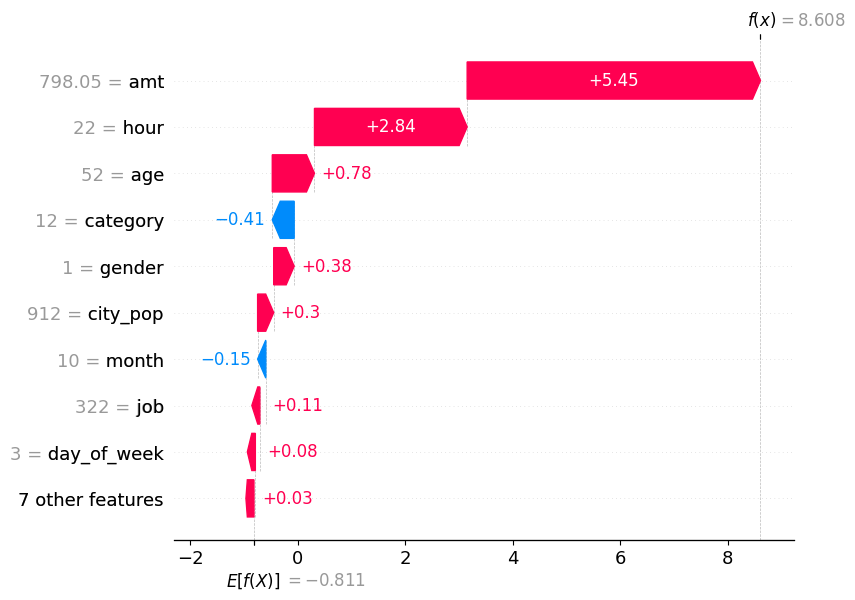

time: 433 ms (started: 2026-06-22 08:04:07 +00:00)


In [ ]:
processed_features = prediction_result["processed_features"]
shap_values = cat_shap_explainer(processed_features)

shap.plots.waterfall(shap_values[0], max_display=10)

# 19. Safe Customer Message Check

The customer message must stay general.

It must not expose:

- exact threshold
- SHAP values
- feature names
- fraud rules
- model internals

In [ ]:
print(response_json["customer_message"]["title"])
print()
print(response_json["customer_message"]["message"])

Transaction Verification Needed

Hi, we noticed an unusual transaction attempt on your card. To help protect your account, we temporarily stopped the transaction and would like to verify that it was initiated by you. If this was you, please confirm and try again.
time: 659 µs (started: 2026-06-22 08:04:07 +00:00)


# 20. Save JSON Example

The generated JSON can be copied later into backend tests or frontend mock data.

In [ ]:
OUTPUT_DIR = "/content/fraud_explainability_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

json_output_path = os.path.join(
    OUTPUT_DIR,
    "sample_explainability_response.json"
)

with open(json_output_path, "w") as f:
    json.dump(response_json, f, indent=4)

print("Saved JSON example:")
print(json_output_path)

Saved JSON example:
/content/fraud_explainability_outputs/sample_explainability_response.json
time: 1.3 ms (started: 2026-06-22 08:04:07 +00:00)


# 21. Backend Mapping

The code tested in this notebook can later be split into backend files:

```text
backend/
  services/
    prediction_service.py
    explanation_service.py
    fraud_decision_service.py
    response_builder.py
```

Suggested mapping:

- `PredictionService` → `prediction_service.py`
- `ExplanationService` → `explanation_service.py`
- `FraudDecisionService` → `fraud_decision_service.py`
- `ResponseBuilder` → `response_builder.py`

# 22. Notebook Summary

This notebook implemented a modular explainability layer for the selected production fraud detection stack.

The prediction flow remains unchanged:

```text
Transaction
→ Preprocessing / feature engineering
→ RF, CatBoost, XGBoost
→ Meta-feature vector [rf_prob, cat_prob, xgb_prob]
→ Logistic Regression meta-model
→ final fraud probability
→ threshold comparison
→ ALLOW / BLOCK
```

The explainability flow is added after prediction:

```text
Prediction result
→ CatBoost SHAP explanation
→ top transaction-level risk factors
→ agent explanation
→ safe customer message
→ frontend JSON response
```

The most important architectural point is that the model does not directly output human explanations.
The explanation layer interprets model behavior after prediction and formats it for the correct audience.